## Offline Distributed Sampler (GCP)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/google/distributed_graph_flow/blob/main/doc/docs/tutorial/gcp_offline_distributed_sampler.ipynb)

This tutorial shows how to generate graph samples with the offline distributed
sampler on Google Cloud (GCP). The sampler runs as an Apache Beam pipeline on
Dataflow, launched through a Vertex AI custom job. This option is well suited
for large graphs (e.g., more than 100 million nodes). For smaller graphs, the
in-process sampler (see the "In-process Sampler" tutorial) is simpler to use.

In this tutorial, you will:

1.  Copy a toy graph (OGB MAG) to a Cloud Storage bucket.
2.  Generate graph samples with the offline distributed sampler.
3.  Read and plot a generated sample.
4.  Train a node classification model on the samples.

**Note:** This tutorial is based on the
`create_graph_samples_offline_distributed_gcp.py` example.

## Installing GF

The sampling runs on GCP, so it does not require a local accelerator. However,
the last section of this tutorial trains a model: make sure your machine has a
GPU or TPU, otherwise training will be slow. If you are using Google Colab, you
can get one for free: go to Edit > Notebook settings and select a GPU or TPU as
the hardware accelerator.

In [ ]:
# Install DGF (Distributed Graph Flow), the Vertex AI SDK, and OGB (for the toy
# dataset).
!pip install dgf ogb google-cloud-aiplatform -U

## Importing libraries

In [ ]:
import dgf  # Import Graph Flow

## Setup

In this example, we generate samples from the OGB MAG dataset. This dataset is
small, but it is sufficient to demonstrate the sampler. To prepare, we
authenticate with GCP and copy OGB MAG to a Cloud Storage bucket.

**Requirements:** You need a GCP project with billing enabled, and with the
Vertex AI, Dataflow, Compute Engine, and Cloud Storage APIs enabled. For
example:

```shell
gcloud services enable aiplatform.googleapis.com dataflow.googleapis.com \
  compute.googleapis.com storage.googleapis.com
```

In [ ]:
# Authenticate with your Google account (in Colab).
from google.colab import auth

auth.authenticate_user()

# Outside of Colab, use instead:
# !gcloud auth login --no-launch-browser
# !gcloud auth application-default login --no-launch-browser

Set the GCP project. Replace `graphflow-experiments-49784` with your own
project ID, here and in the rest of the tutorial:

In [ ]:
!gcloud config set project "graphflow-experiments-49784"

Create a Cloud Storage bucket to store the graph and the generated samples.
Bucket names are globally unique: replace `dgf-tutorial-bucket` with a name of
your own, here and in the rest of the tutorial.

In [ ]:
!gcloud storage buckets create gs://dgf-tutorial-bucket --location=us-central1

DGF provides direct access to OGB MAG. Let's download it and copy it to our
bucket:

In [ ]:
graph, schema = dgf.io.fetch_ogb_graph("mag")
dgf.io.write_graph(graph, schema, "gs://dgf-tutorial-bucket/graph")

Let's check that the graph files are there:

In [ ]:
!gcloud storage ls gs://dgf-tutorial-bucket/graph

gs://dgf-tutorial-bucket/graph/edgesets_$folder$
gs://dgf-tutorial-bucket/graph/metadata.json
gs://dgf-tutorial-bucket/graph/nodesets_$folder$
gs://dgf-tutorial-bucket/graph/schema.json
gs://dgf-tutorial-bucket/graph/edgesets/
gs://dgf-tutorial-bucket/graph/nodesets/


It is always a good idea to check the schema of a graph:

In [ ]:
dgf.print.schema(
    dgf.io.read_schema("gs://dgf-tutorial-bucket/graph/schema.json")
)

Graph Schema:

Node Sets:
  author:
    | Feature   | Format   | Semantic   | Shape   | Detail   |
    |-----------|----------|------------|---------|----------|
    | #id       | BYTES    | PRIMARY_ID | None    |          |

  field_of_study:
    | Feature   | Format   | Semantic   | Shape   | Detail   |
    |-----------|----------|------------|---------|----------|
    | #id       | BYTES    | PRIMARY_ID | None    |          |

  institution:
    | Feature   | Format   | Semantic   | Shape   | Detail   |
    |-----------|----------|------------|---------|----------|
    | #id       | BYTES    | PRIMARY_ID | None    |          |

  paper:
    | Feature   | Format     | Semantic    | Shape   | Detail   |
    |-----------|------------|-------------|---------|----------|
    | #id       | BYTES      | PRIMARY_ID  | None    |          |
    | #split    | BYTES      | CATEGORICAL | None    |          |
    | feat      | FLOAT_32   | EMBEDDING   | (128,)  |          |
    | labels    | INTE

## Run the sampler

The sampler runs as the default Compute Engine service account of your
project. Give this service account read and write access to the bucket:

In [ ]:
!gcloud storage buckets add-iam-policy-binding "gs://dgf-tutorial-bucket" \
  --member="serviceAccount:$(gcloud projects describe graphflow-experiments-49784 --format='value(projectNumber)')-compute@developer.gserviceaccount.com" \
  --role="roles/storage.objectAdmin"

The sampling plan defines how the graph is traversed to build each sample. In
most cases, a `SimpleSamplingConfig` is sufficient: it specifies the seed
nodeset (i.e., the nodes to generate samples for), the number of hops, and the
number of neighbors to sample at each hop (the hop width). For finer control
(e.g., configuring each hop individually), use a `SamplingPlan` instead.

In [ ]:
plan = dgf.sampling.SimpleSamplingConfig(
    seed_nodeset="paper",
    num_hops=2,
    hop_width=5,
)

Then, run the sampler. With `blocking=True`, the function waits until the
samples are generated and logs the progress of the job:

In [ ]:
dgf.sampling.offline_distributed_sampler_gcp(
    input_path="gs://dgf-tutorial-bucket/graph",
    output_path="gs://dgf-tutorial-bucket/samples",
    project="graphflow-experiments-49784",
    plan=plan,
    num_workers=5,  # Increase for larger graphs.
    num_seeds=10000,  # Generate 10k samples from randomly selected seed nodes.
    blocking=True,  # Wait until the samples are generated.
)

Reading graph schema from gs://dgf-tutorial-bucket/graph/schema.json
Writing sampling plan to gs://dgf-tutorial-bucket/samples/sampling_config.json
Submitting Vertex AI CustomJob 'dgf-distributed-sampler-glassbox-20260924114442'...
Creating CustomJob
CustomJob created. Resource name: projects/569105783505/locations/us-central1/customJobs/3683233532072689664
To use this CustomJob in another session:
custom_job = aiplatform.CustomJob.get('projects/569105783505/locations/us-central1/customJobs/3683233532072689664')
View Custom Job:
https://console.cloud.google.com/agent-platform/locations/us-central1/training/3683233532072689664?project=569105783505
Vertex AI CustomJob created: projects/569105783505/locations/us-central1/customJobs/3683233532072689664
  Cloud Console: https://console.cloud.google.com/vertex-ai/locations/us-central1/training/3683233532072689664?project=graphflow-experiments-49784
  Cloud Logging: https://console.cloud.google.com/logs/viewer?project=graphflow-experiments-49

Distributed Sampler [1/4: Job submitted]:   0%|          | 0/4 [00:00<?, ?stage/s]

Job status changed to: Queued (elapsed: 0s)


Distributed Sampler [2/4: Provisioning Vertex AI worker]:  25%|██▌       | 1/4 [00:00<00:02,  1.44stage/s, Status: Queued | Elapsed: 0s]

Job status changed to: Pending (elapsed: 6s)


...

Distributed Sampler [3/4: Running Dataflow distributed sampler]:  50%|█████     | 2/4 [08:53<01:58, 59.29s/stage, Status: Running | Elapsed: 8m 53s]

Job status changed to: Succeeded (elapsed: 8m 58s)


Distributed Sampler [4/4: Completed]:  75%|███████▌  | 3/4 [08:58<02:59, 179.65s/stage, Success in 8m 58s]

CustomJob completed successfully: projects/569105783505/locations/us-central1/customJobs/3683233532072689664 in 8m 58s
Total duration: 9m 02s


resource name: projects/569105783505/locations/us-central1/customJobs/3683233532072689664

**Remarks:**

-   MAG is a small dataset: most of the time is spent setting up the job.
-   After a few seconds, the job appears in the
    [Dataflow console](https://console.cloud.google.com/dataflow/jobs).
-   Without `num_seeds`, one sample is generated for each node of the seed
    nodeset. Use `num_samples_per_seed` to generate multiple samples per seed
    node, or `input_seeds` / `filter_seed_node` to control which nodes are used
    as seeds.

Let's list the generated sample files:

In [ ]:
!gcloud storage ls gs://dgf-tutorial-bucket/samples

gs://dgf-tutorial-bucket/samples/samples-00000-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00001-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00002-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00003-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00004-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00005-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00006-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00007-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00008-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00009-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00010-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00011-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00012-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00013-of-00020.tfrecord.gz
gs://dgf-tutorial-bucket/samples/samples-00014-o

Samples are stored as TF-GNN graphs in sharded TFRecord files, next to their
schema. Let's read the first sample:

In [ ]:
sample_schema = dgf.io.read_schema(
    "gs://dgf-tutorial-bucket/samples/schema.json"
)
sample_generator = dgf.io.read_tfgnn_graphs(
    "gs://dgf-tutorial-bucket/samples/samples@*.tfrecord.gz", sample_schema
)
sample = next(iter(sample_generator))

Let's plot it. `features=False` hides the features, which makes the topology
of the sample easier to see:

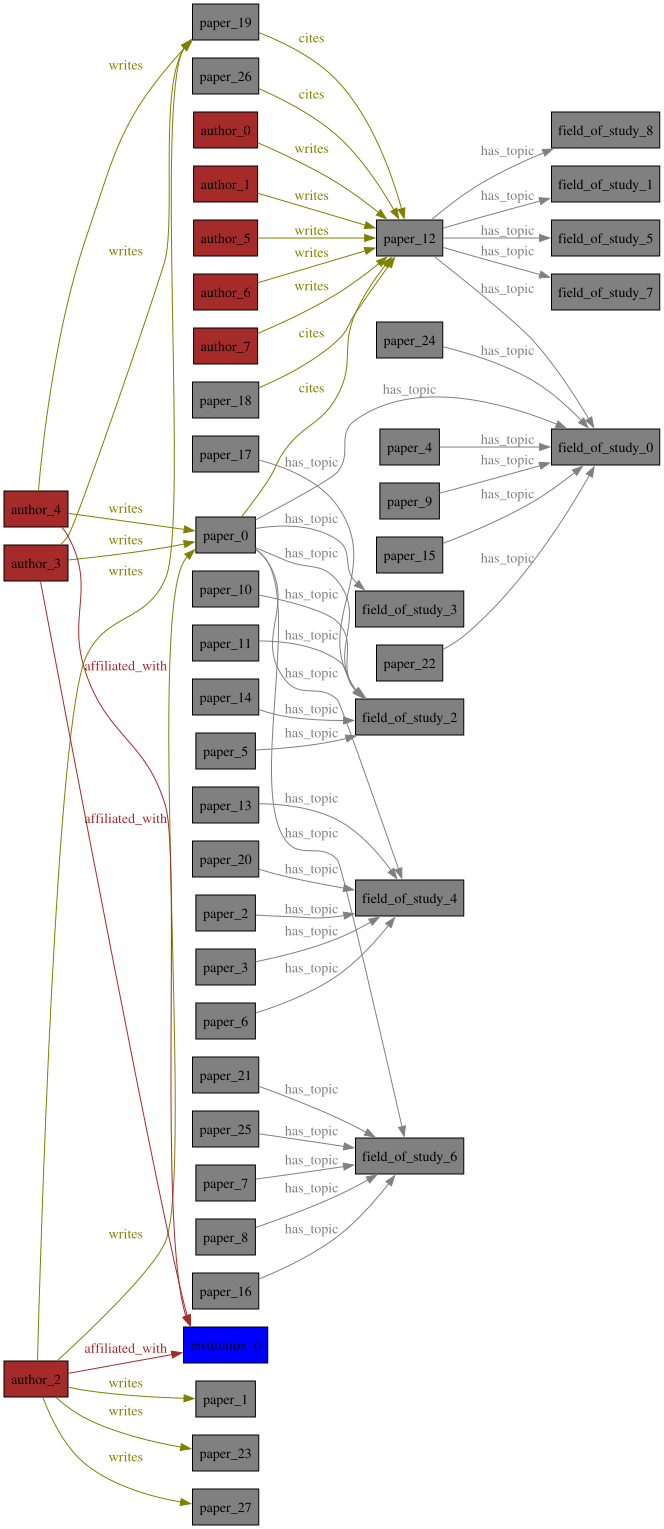

In [ ]:
dgf.plot.plot_graph(sample, sample_schema, features=False)

The graph samples can be used directly to train a model with the simple API:

**Note:** Reduce `num_train_steps` if you don't have a GPU/TPU.

In [ ]:
model = dgf.learning.train_node_model(
    graph="gs://dgf-tutorial-bucket/samples/samples@*.tfrecord.gz",
    schema=sample_schema,
    target_column="labels",
    target_nodeset="paper",
    num_train_steps=1000,
    valid_every_n_steps=100,
    verbose=1,
)

[Warning] The model is trained on graph samples and no `sampling_plan` is provided. This is fine, but it is recommended to provide the `sampling_plan` used to generate those samples to make the model easier to use later (e.g. to generate predictions from a full graph).


Preparing dataset


[Warning] No normalizer created for node set 'author', feature '#id'.
[Warning] No normalizer created for node set 'field_of_study', feature '#id'.
[Warning] No normalizer created for node set 'institution', feature '#id'.
[Warning] No normalizer created for node set 'paper', feature '#id'.


Preparing dataset finished in 18.57 seconds
Caching validation dataset
Caching validation dataset finished in 9.65 seconds
Number of cache validation batches: 313
Training model
Generate first batch to initialize model
Create model variables
...Tracing model
Create model variables finished in 7.36 seconds
Will validate model every 100 step(s)
Will checkpoint model every 1000 step(s)
Start training. The first two steps are generally slow.


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Training: 100%|██████████| 1000/1000 [00:49<00:00, 20.15it/s, step=1000, train-accuracy=0.3072, train-loss=2.8659, valid-accuracy=0.3116, valid-loss=2.7516]

Restoring best model parameters with validation loss 2.735185 from step 1000
Final metrics: {'step': '1000', 'train-accuracy': '0.3072', 'train-loss': '2.8659', 'valid-accuracy': '0.3116', 'valid-loss': '2.7516'}
Training model finished in 62.03 seconds
Final model evaluation
Evaluating model on generator



Evaluation:   0%|          | 8/10000 [00:04<1:03:52,  2.61it/s]

...Tracing model


Evaluation: 100%|██████████| 10000/10000 [00:12<00:00, 773.43it/s]


In [ ]:
model.describe()

Type,Node prediction model - Predict the value of a node feature.
Target nodeset,paper
Target column,labels
Number of label classes,349
WARNING,"The model is trained on graph samples and no `sampling_plan` is provided. This is fine, but it is recommended to provide the `sampling_plan` used to generate those samples to make the model easier to use later (e.g. to generate predictions from a full graph)."
WARNING,"No normalizer created for node set 'author', feature '#id'."
WARNING,"No normalizer created for node set 'field_of_study', feature '#id'."
WARNING,"No normalizer created for node set 'institution', feature '#id'."
WARNING,"No normalizer created for node set 'paper', feature '#id'."
Accuracy,0.3168
Num Examples,10000


## Clean up

To avoid storage costs, delete the bucket and its content when you are done:

```shell
gcloud storage rm --recursive gs://dgf-tutorial-bucket
```